GA-OPT-LSTM

In [1]:
!pip install -q numpy pandas matplotlib scikit-learn yfinance tensorflow tqdm

Imports and configuration

In [4]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from tqdm.notebook import tqdm
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_ROOT = Path(".")
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = PROJECT_ROOT / "figures"
MODEL_DIR = PROJECT_ROOT / "models"

for d in [DATA_DIR, OUTPUT_DIR, FIGURE_DIR, MODEL_DIR]:
    d.mkdir(exist_ok=True)

# Same as paper
LOOKBACK = 8
FEATURE_COLUMNS = ["Open", "High", "Low", "Close", "Volume"]
TARGET_COLUMN = "Close"

START_DATE = "2010-03-13"
END_DATE = "2025-03-13"

# Paper uses 3 stock datasets
TICKERS = {
    "VV": "600300.SS",
    "LH": "600186.SS",
    "SY": "600429.SS",
}

# Run all datasets
RUN_STOCKS = ["VV", "LH", "SY"]

# First run: keep True
# Final experiment: set False
FAST_MODE = True

if FAST_MODE:
    POP_SIZE = 4
    MAX_ITER = 2
    FITNESS_EPOCHS = 4
    FINAL_EPOCHS = 30
    FINAL_PATIENCE = 6
else:
    # Paper-like setting
    POP_SIZE = 20
    MAX_ITER = 15
    FITNESS_EPOCHS = 10
    FINAL_EPOCHS = 80
    FINAL_PATIENCE = 15

print("TensorFlow:", tf.__version__)
print("FAST_MODE:", FAST_MODE)
print("Stocks:", RUN_STOCKS)
print("Lookback window:", LOOKBACK)

TensorFlow: 2.21.0
FAST_MODE: True
Stocks: ['VV', 'LH', 'SY']
Lookback window: 8


Download dataset automatically

In [5]:
def download_stock_data(symbol, name):
    csv_path = DATA_DIR / f"{name}_{symbol}.csv"
    
    if csv_path.exists():
        print(f"Loading cached data: {csv_path}")
        df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
    else:
        print(f"Downloading {name}: {symbol}")
        df = yf.download(
            symbol,
            start=START_DATE,
            end=END_DATE,
            auto_adjust=False,
            progress=False
        )
        
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        
        if df.empty:
            raise ValueError(f"No data downloaded for {name} / {symbol}. Try checking Yahoo Finance ticker.")
        
        df.to_csv(csv_path)
        print(f"Saved: {csv_path}")
    
    # Keep only paper features
    df = df[FEATURE_COLUMNS].dropna()
    
    return df


stock_data = {}

for name in RUN_STOCKS:
    symbol = TICKERS[name]
    df = download_stock_data(symbol, name)
    stock_data[name] = df
    
    print("=" * 70)
    print(f"{name} / {symbol}")
    print("Shape:", df.shape)
    print("Start:", df.index.min())
    print("End:", df.index.max())
    display(df.head())

Loading cached data: data/VV_600300.SS.csv
VV / 600300.SS
Shape: (3641, 5)
Start: 2010-03-15 00:00:00
End: 2025-03-12 00:00:00


,Open,High,Low,Close,Volume
Date,,,,,
2010-03-15,7.54,7.56,7.30,7.34,10584532
2010-03-16,7.34,7.39,7.30,7.38,6626677
2010-03-17,7.38,7.55,7.38,7.55,10636735
2010-03-18,7.55,7.59,7.48,7.50,8711146
2010-03-19,7.49,7.55,7.43,7.55,9717640


Saved: data/LH_600186.SS.csv
LH / 600186.SS
Shape: (3641, 5)
Start: 2010-03-15 00:00:00
End: 2025-03-12 00:00:00


Price,Open,High,Low,Close,Volume
Date,,,,,
2010-03-15,6.60,6.70,6.48,6.67,26022391
2010-03-16,6.61,6.90,6.61,6.74,27509550
2010-03-17,6.76,7.20,6.66,7.07,71824003
2010-03-18,7.03,7.10,6.91,7.01,48727846
2010-03-19,7.03,7.14,6.92,7.07,44382278


Saved: data/SY_600429.SS.csv
SY / 600429.SS
Shape: (3641, 5)
Start: 2010-03-15 00:00:00
End: 2025-03-12 00:00:00


Price,Open,High,Low,Close,Volume
Date,,,,,
2010-03-15,6.93,6.97,6.85,6.93,2971399
2010-03-16,6.95,6.99,6.89,6.97,2242487
2010-03-17,6.97,7.10,6.94,7.10,4189599
2010-03-18,7.08,7.29,7.07,7.28,11017834
2010-03-19,7.27,7.46,7.21,7.44,18461990


Plot closing price

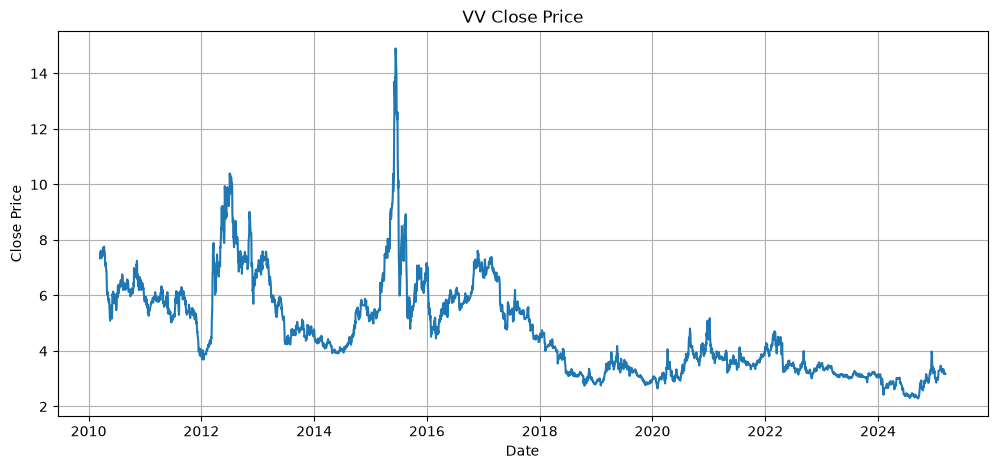

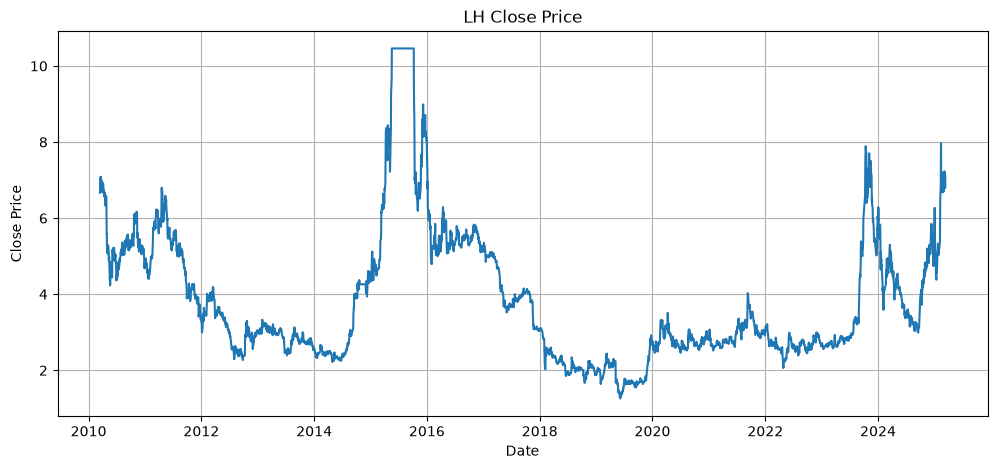

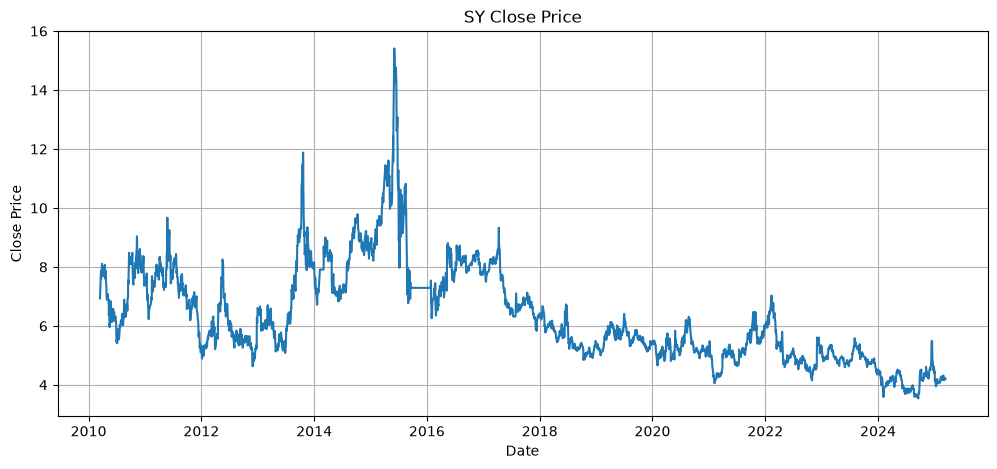

In [6]:
for name, df in stock_data.items():
    plt.figure(figsize=(12, 5))
    plt.plot(df.index, df["Close"])
    plt.title(f"{name} Close Price")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.grid(True)
    plt.show()

Preprocessing with lookback window = 8

In [7]:
def create_sequences(features_scaled, close_scaled, lookback=8):
    X, y = [], []
    
    for i in range(lookback, len(features_scaled)):
        X.append(features_scaled[i - lookback:i])
        y.append(close_scaled[i])
    
    return np.array(X), np.array(y)


def prepare_data(df, lookback=8, train_ratio=0.8):
    split_idx = int(len(df) * train_ratio)
    
    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()
    
    feature_scaler = MinMaxScaler()
    target_scaler = MinMaxScaler()
    
    train_features_scaled = feature_scaler.fit_transform(train_df[FEATURE_COLUMNS])
    test_features_scaled = feature_scaler.transform(test_df[FEATURE_COLUMNS])
    
    train_close_scaled = target_scaler.fit_transform(train_df[[TARGET_COLUMN]])
    test_close_scaled = target_scaler.transform(test_df[[TARGET_COLUMN]])
    
    X_train, y_train = create_sequences(
        train_features_scaled,
        train_close_scaled,
        lookback
    )
    
    X_test, y_test = create_sequences(
        test_features_scaled,
        test_close_scaled,
        lookback
    )
    
    test_dates = test_df.index[lookback:]
    
    return {
        "X_train": X_train,
        "y_train": y_train,
        "X_test": X_test,
        "y_test": y_test,
        "test_dates": test_dates,
        "feature_scaler": feature_scaler,
        "target_scaler": target_scaler,
        "train_df": train_df,
        "test_df": test_df,
    }


prepared = {}

for name, df in stock_data.items():
    prepared[name] = prepare_data(df, LOOKBACK)
    print(name)
    print("X_train:", prepared[name]["X_train"].shape)
    print("y_train:", prepared[name]["y_train"].shape)
    print("X_test :", prepared[name]["X_test"].shape)
    print("y_test :", prepared[name]["y_test"].shape)

VV
X_train: (2904, 8, 5)
y_train: (2904, 1)
X_test : (721, 8, 5)
y_test : (721, 1)
LH
X_train: (2904, 8, 5)
y_train: (2904, 1)
X_test : (721, 8, 5)
y_test : (721, 1)
SY
X_train: (2904, 8, 5)
y_train: (2904, 1)
X_test : (721, 8, 5)
y_test : (721, 1)


Metrics and LSTM model

In [ ]:
def build_lstm_model(input_shape, units, dropout, learning_rate):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(int(units)),
        layers.Dropout(float(dropout)),
        layers.Dense(1)
    ])
    
    model.compile(
        optimizer=optimizers.Adam(learning_rate=float(learning_rate)),
        loss="mse"
    )
    
    return model


def regression_metrics(y_true_raw, y_pred_raw):
    y_true_raw = y_true_raw.reshape(-1)
    y_pred_raw = y_pred_raw.reshape(-1)
    
    mae = mean_absolute_error(y_true_raw, y_pred_raw)
    rmse = np.sqrt(mean_squared_error(y_true_raw, y_pred_raw))
    
    denominator = np.where(y_true_raw == 0, 1e-8, y_true_raw)
    mape = np.mean(np.abs((y_true_raw - y_pred_raw) / denominator)) * 100
    
    r2 = r2_score(y_true_raw, y_pred_raw)
    
    return {
        "MAE": mae,
        "MAPE": mape,
        "RMSE": rmse,
        "R2": r2,
    }


def inverse_target(y_scaled, target_scaler):
    return target_scaler.inverse_transform(y_scaled.reshape(-1, 1)).reshape(-1)

Hyperparameter decoder

In [ ]:
# Search space like the paper
# units: [256, 512]
# dropout: [0.05, 0.15]
# batch_size: [16, 128]
# learning_rate: [1e-4, 1e-2]

BOUNDS = np.array([
    [256, 512],
    [0.05, 0.15],
    [16, 128],
    [1e-4, 1e-2],
], dtype=float)

PARAM_NAMES = ["units", "dropout", "batch_size", "learning_rate"]


def clip_position(position):
    position = np.array(position, dtype=float)
    return np.clip(position, BOUNDS[:, 0], BOUNDS[:, 1])


def decode_position(position):
    position = clip_position(position)
    
    units = int(round(position[0]))
    dropout = float(position[1])
    batch_size = int(round(position[2]))
    learning_rate = float(position[3])
    
    units = max(1, units)
    batch_size = max(1, batch_size)
    
    return {
        "units": units,
        "dropout": dropout,
        "batch_size": batch_size,
        "learning_rate": learning_rate,
    }


def print_params(title, position):
    params = decode_position(position)
    print(title)
    for k, v in params.items():
        print(f"  {k}: {v}")

Fitness function

In [ ]:
class LSTMObjective:
    def __init__(self, X_train, y_train, input_shape):
        self.X_train = X_train
        self.y_train = y_train
        self.input_shape = input_shape
        self.cache = {}
    
    def __call__(self, position):
        params = decode_position(position)
        
        # Cache repeated evaluations
        key = (
            params["units"],
            round(params["dropout"], 4),
            params["batch_size"],
            round(params["learning_rate"], 6),
        )
        
        if key in self.cache:
            return self.cache[key]
        
        split_idx = int(len(self.X_train) * 0.9)
        X_tr = self.X_train[:split_idx]
        y_tr = self.y_train[:split_idx]
        X_val = self.X_train[split_idx:]
        y_val = self.y_train[split_idx:]
        
        tf.keras.backend.clear_session()
        
        model = build_lstm_model(
            input_shape=self.input_shape,
            units=params["units"],
            dropout=params["dropout"],
            learning_rate=params["learning_rate"]
        )
        
        es = callbacks.EarlyStopping(
            monitor="loss",
            patience=3,
            restore_best_weights=True
        )
        
        model.fit(
            X_tr,
            y_tr,
            epochs=FITNESS_EPOCHS,
            batch_size=params["batch_size"],
            shuffle=False,
            verbose=0,
            callbacks=[es]
        )
        
        pred_val = model.predict(X_val, verbose=0).reshape(-1)
        y_val_flat = y_val.reshape(-1)
        
        mse = mean_squared_error(y_val_flat, pred_val)
        r2 = r2_score(y_val_flat, pred_val)
        
        # Paper-like idea: weighted MSE + (1 - R2)
        score = mse + (1.0 - r2)
        
        if np.isnan(score) or np.isinf(score):
            score = 1e9
        
        self.cache[key] = score
        return score

Pure WaOA optimizer

In [ ]:
def initialize_population(pop_size):
    low = BOUNDS[:, 0]
    high = BOUNDS[:, 1]
    return low + np.random.rand(pop_size, len(low)) * (high - low)


def evaluate_population(population, objective):
    fitness = np.array([objective(ind) for ind in population])
    return fitness


def waoa_optimize(objective, pop_size=10, max_iter=10):
    population = initialize_population(pop_size)
    fitness = evaluate_population(population, objective)
    
    best_idx = np.argmin(fitness)
    best_position = population[best_idx].copy()
    best_score = fitness[best_idx]
    
    history = []
    
    for t in tqdm(range(1, max_iter + 1), desc="WaOA"):
        # Update best
        best_idx = np.argmin(fitness)
        if fitness[best_idx] < best_score:
            best_score = fitness[best_idx]
            best_position = population[best_idx].copy()
        
        # Phase 1: feeding strategy / exploration
        for i in range(pop_size):
            rand = np.random.rand(population.shape[1])
            I = np.random.randint(1, 3, size=population.shape[1])
            
            candidate = population[i] + rand * (best_position - I * population[i])
            candidate = clip_position(candidate)
            candidate_score = objective(candidate)
            
            if candidate_score < fitness[i]:
                population[i] = candidate
                fitness[i] = candidate_score
        
        # Phase 2: migration
        for i in range(pop_size):
            k = np.random.choice([idx for idx in range(pop_size) if idx != i])
            rand = np.random.rand(population.shape[1])
            I = np.random.randint(1, 3, size=population.shape[1])
            
            if fitness[k] < fitness[i]:
                candidate = population[i] + rand * (population[k] - I * population[i])
            else:
                candidate = population[i] + rand * (population[i] - population[k])
            
            candidate = clip_position(candidate)
            candidate_score = objective(candidate)
            
            if candidate_score < fitness[i]:
                population[i] = candidate
                fitness[i] = candidate_score
        
        # Phase 3: escaping/fighting predators / exploitation
        for i in range(pop_size):
            lb_local = BOUNDS[:, 0] / t
            ub_local = BOUNDS[:, 1] / t
            rand = np.random.rand(population.shape[1])
            
            local_step = lb_local + (ub_local - rand * lb_local)
            sign = np.random.choice([-1, 1], size=population.shape[1])
            
            candidate = population[i] + sign * local_step * np.random.rand(population.shape[1])
            candidate = clip_position(candidate)
            candidate_score = objective(candidate)
            
            if candidate_score < fitness[i]:
                population[i] = candidate
                fitness[i] = candidate_score
        
        best_idx = np.argmin(fitness)
        if fitness[best_idx] < best_score:
            best_score = fitness[best_idx]
            best_position = population[best_idx].copy()
        
        history.append(best_score)
        print(f"Iter {t}/{max_iter} | Best score: {best_score:.6f} | Params: {decode_position(best_position)}")
    
    return best_position, best_score, history

GA operators

In [ ]:
def tournament_selection(population, fitness, tournament_size=3):
    selected_indices = np.random.choice(len(population), tournament_size, replace=True)
    best_local_idx = selected_indices[np.argmin(fitness[selected_indices])]
    return population[best_local_idx].copy()


def arithmetic_crossover(parent1, parent2, crossover_rate=0.9):
    if np.random.rand() > crossover_rate:
        return parent1.copy(), parent2.copy()
    
    alpha = np.random.rand()
    child1 = alpha * parent1 + (1 - alpha) * parent2
    child2 = alpha * parent2 + (1 - alpha) * parent1
    
    return clip_position(child1), clip_position(child2)


def gaussian_mutation(individual, mutation_rate=0.3, mutation_scale=0.1):
    child = individual.copy()
    
    for j in range(len(child)):
        if np.random.rand() < mutation_rate:
            search_range = BOUNDS[j, 1] - BOUNDS[j, 0]
            child[j] += np.random.normal(0, mutation_scale * search_range)
    
    return clip_position(child)


def ga_step(population, fitness, objective, elite_count=1):
    pop_size = len(population)
    
    elite_indices = np.argsort(fitness)[:elite_count]
    new_population = [population[i].copy() for i in elite_indices]
    
    while len(new_population) < pop_size:
        p1 = tournament_selection(population, fitness)
        p2 = tournament_selection(population, fitness)
        
        c1, c2 = arithmetic_crossover(p1, p2)
        c1 = gaussian_mutation(c1)
        c2 = gaussian_mutation(c2)
        
        new_population.append(c1)
        if len(new_population) < pop_size:
            new_population.append(c2)
    
    new_population = np.array(new_population)
    new_fitness = evaluate_population(new_population, objective)
    
    return new_population, new_fitness

Hybrid GA-WaOA-LSTM optimizer

In [ ]:
def waoa_refine_one_iteration(population, fitness, objective, iteration_number=1):
    pop_size = len(population)
    
    best_idx = np.argmin(fitness)
    best_position = population[best_idx].copy()
    
    # Light WaOA refinement: one pass through the three phases
    for i in range(pop_size):
        rand = np.random.rand(population.shape[1])
        I = np.random.randint(1, 3, size=population.shape[1])
        candidate = population[i] + rand * (best_position - I * population[i])
        candidate = clip_position(candidate)
        candidate_score = objective(candidate)
        
        if candidate_score < fitness[i]:
            population[i] = candidate
            fitness[i] = candidate_score
    
    for i in range(pop_size):
        k = np.random.choice([idx for idx in range(pop_size) if idx != i])
        rand = np.random.rand(population.shape[1])
        I = np.random.randint(1, 3, size=population.shape[1])
        
        if fitness[k] < fitness[i]:
            candidate = population[i] + rand * (population[k] - I * population[i])
        else:
            candidate = population[i] + rand * (population[i] - population[k])
        
        candidate = clip_position(candidate)
        candidate_score = objective(candidate)
        
        if candidate_score < fitness[i]:
            population[i] = candidate
            fitness[i] = candidate_score
    
    t = max(1, iteration_number)
    for i in range(pop_size):
        lb_local = BOUNDS[:, 0] / t
        ub_local = BOUNDS[:, 1] / t
        rand = np.random.rand(population.shape[1])
        local_step = lb_local + (ub_local - rand * lb_local)
        sign = np.random.choice([-1, 1], size=population.shape[1])
        
        candidate = population[i] + sign * local_step * np.random.rand(population.shape[1])
        candidate = clip_position(candidate)
        candidate_score = objective(candidate)
        
        if candidate_score < fitness[i]:
            population[i] = candidate
            fitness[i] = candidate_score
    
    return population, fitness


def ga_waoa_optimize(objective, pop_size=10, max_iter=10):
    population = initialize_population(pop_size)
    fitness = evaluate_population(population, objective)
    
    best_idx = np.argmin(fitness)
    best_position = population[best_idx].copy()
    best_score = fitness[best_idx]
    
    history = []
    
    for gen in tqdm(range(1, max_iter + 1), desc="GA-WaOA"):
        # GA global search
        population, fitness = ga_step(
            population,
            fitness,
            objective,
            elite_count=1
        )
        
        # WaOA local/global refinement
        population, fitness = waoa_refine_one_iteration(
            population,
            fitness,
            objective,
            iteration_number=gen
        )
        
        best_idx = np.argmin(fitness)
        if fitness[best_idx] < best_score:
            best_score = fitness[best_idx]
            best_position = population[best_idx].copy()
        
        history.append(best_score)
        print(f"Gen {gen}/{max_iter} | Best score: {best_score:.6f} | Params: {decode_position(best_position)}")
    
    return best_position, best_score, history

Train final model using best hyperparameters

In [ ]:
def train_final_model(data_dict, best_position, model_name, stock_name):
    params = decode_position(best_position)
    
    X_train = data_dict["X_train"]
    y_train = data_dict["y_train"]
    X_test = data_dict["X_test"]
    y_test = data_dict["y_test"]
    target_scaler = data_dict["target_scaler"]
    
    tf.keras.backend.clear_session()
    
    model = build_lstm_model(
        input_shape=X_train.shape[1:],
        units=params["units"],
        dropout=params["dropout"],
        learning_rate=params["learning_rate"]
    )
    
    es = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=FINAL_PATIENCE,
        restore_best_weights=True
    )
    
    history = model.fit(
        X_train,
        y_train,
        validation_split=0.1,
        epochs=FINAL_EPOCHS,
        batch_size=params["batch_size"],
        shuffle=False,
        verbose=1,
        callbacks=[es]
    )
    
    pred_train_scaled = model.predict(X_train, verbose=0)
    pred_test_scaled = model.predict(X_test, verbose=0)
    
    y_train_raw = inverse_target(y_train, target_scaler)
    y_test_raw = inverse_target(y_test, target_scaler)
    pred_train_raw = inverse_target(pred_train_scaled, target_scaler)
    pred_test_raw = inverse_target(pred_test_scaled, target_scaler)
    
    train_metrics = regression_metrics(y_train_raw, pred_train_raw)
    test_metrics = regression_metrics(y_test_raw, pred_test_raw)
    
    save_path = MODEL_DIR / f"{stock_name}_{model_name}.keras"
    model.save(save_path)
    
    return {
        "model": model,
        "history": history,
        "params": params,
        "train_metrics": train_metrics,
        "test_metrics": test_metrics,
        "y_train_raw": y_train_raw,
        "y_test_raw": y_test_raw,
        "pred_train_raw": pred_train_raw,
        "pred_test_raw": pred_test_raw,
        "model_path": save_path,
    }

Run experiment

In [ ]:
all_results = []
all_predictions = {}
all_histories = {}

for stock_name in RUN_STOCKS:
    data_dict = prepared[stock_name]
    
    print("=" * 90)
    print(f"Running stock dataset: {stock_name}")
    print("=" * 90)
    
    X_train = data_dict["X_train"]
    y_train = data_dict["y_train"]
    input_shape = X_train.shape[1:]
    
    objective = LSTMObjective(X_train, y_train, input_shape)
    
    # ------------------------------------------------------------
    # 1. Baseline LSTM
    # ------------------------------------------------------------
    baseline_position = np.array([256, 0.10, 32, 0.001])
    print_params("Baseline LSTM params", baseline_position)
    
    baseline_output = train_final_model(
        data_dict,
        baseline_position,
        model_name="Baseline_LSTM",
        stock_name=stock_name
    )
    
    all_results.append({
        "Stock": stock_name,
        "Model": "Baseline-LSTM",
        **{f"Train_{k}": v for k, v in baseline_output["train_metrics"].items()},
        **{f"Test_{k}": v for k, v in baseline_output["test_metrics"].items()},
        **baseline_output["params"],
    })
    
    all_predictions[(stock_name, "Baseline-LSTM")] = baseline_output
    
    # ------------------------------------------------------------
    # 2. WaOA-LSTM
    # ------------------------------------------------------------
    best_waoa_position, best_waoa_score, waoa_history = waoa_optimize(
        objective,
        pop_size=POP_SIZE,
        max_iter=MAX_ITER
    )
    
    print_params("Best WaOA-LSTM params", best_waoa_position)
    
    waoa_output = train_final_model(
        data_dict,
        best_waoa_position,
        model_name="WaOA_LSTM",
        stock_name=stock_name
    )
    
    all_results.append({
        "Stock": stock_name,
        "Model": "WaOA-LSTM",
        **{f"Train_{k}": v for k, v in waoa_output["train_metrics"].items()},
        **{f"Test_{k}": v for k, v in waoa_output["test_metrics"].items()},
        **waoa_output["params"],
    })
    
    all_predictions[(stock_name, "WaOA-LSTM")] = waoa_output
    all_histories[(stock_name, "WaOA-LSTM")] = waoa_history
    
    # ------------------------------------------------------------
    # 3. GA-WaOA-LSTM
    # ------------------------------------------------------------
    best_hybrid_position, best_hybrid_score, hybrid_history = ga_waoa_optimize(
        objective,
        pop_size=POP_SIZE,
        max_iter=MAX_ITER
    )
    
    print_params("Best GA-WaOA-LSTM params", best_hybrid_position)
    
    hybrid_output = train_final_model(
        data_dict,
        best_hybrid_position,
        model_name="GA_WaOA_LSTM",
        stock_name=stock_name
    )
    
    all_results.append({
        "Stock": stock_name,
        "Model": "GA-WaOA-LSTM",
        **{f"Train_{k}": v for k, v in hybrid_output["train_metrics"].items()},
        **{f"Test_{k}": v for k, v in hybrid_output["test_metrics"].items()},
        **hybrid_output["params"],
    })
    
    all_predictions[(stock_name, "GA-WaOA-LSTM")] = hybrid_output
    all_histories[(stock_name, "GA-WaOA-LSTM")] = hybrid_history
    
    # ------------------------------------------------------------
    # Convergence plot
    # ------------------------------------------------------------
    plt.figure(figsize=(8, 4))
    plt.plot(waoa_history, marker="o", label="WaOA-LSTM")
    plt.plot(hybrid_history, marker="o", label="GA-WaOA-LSTM")
    plt.title(f"{stock_name} Optimization Convergence")
    plt.xlabel("Iteration / Generation")
    plt.ylabel("Fitness score, lower is better")
    plt.legend()
    plt.grid(True)
    
    fig_path = FIGURE_DIR / f"{stock_name}_convergence.png"
    plt.savefig(fig_path, dpi=200, bbox_inches="tight")
    plt.show()
    
    print(f"Saved convergence figure: {fig_path}")

Results table

In [ ]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(["Stock", "Test_RMSE"])

display(results_df)

results_path = OUTPUT_DIR / "results_metrics.csv"
results_df.to_csv(results_path, index=False)

print(f"Saved results to: {results_path}")

Plot actual vs predicted

In [ ]:
for (stock_name, model_name), output in all_predictions.items():
    data_dict = prepared[stock_name]
    test_dates = data_dict["test_dates"]
    
    plt.figure(figsize=(12, 5))
    plt.plot(test_dates, output["y_test_raw"], label="Actual")
    plt.plot(test_dates, output["pred_test_raw"], label="Predicted")
    plt.title(f"{stock_name} - {model_name} - Test Set Prediction")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.legend()
    plt.grid(True)
    
    fig_path = FIGURE_DIR / f"{stock_name}_{model_name}_prediction.png"
    plt.savefig(fig_path, dpi=200, bbox_inches="tight")
    plt.show()
    
    print(f"Saved figure: {fig_path}")

Best model summary

In [ ]:
best_rows = results_df.loc[results_df.groupby("Stock")["Test_RMSE"].idxmin()]
display(best_rows)

for _, row in best_rows.iterrows():
    print("=" * 60)
    print(f"Best model for {row['Stock']}: {row['Model']}")
    print(f"Test MAE : {row['Test_MAE']:.6f}")
    print(f"Test MAPE: {row['Test_MAPE']:.4f}%")
    print(f"Test RMSE: {row['Test_RMSE']:.6f}")
    print(f"Test R2  : {row['Test_R2']:.6f}")
    print("Best hyperparameters:")
    print(f"  units        : {row['units']}")
    print(f"  dropout      : {row['dropout']}")
    print(f"  batch_size   : {row['batch_size']}")
    print(f"  learning_rate: {row['learning_rate']}")